## Model Building (2023+ Data & Expanded Features - RF/LGBM Focus)
- Fetch/Load data from 2023 season onwards.
- Feature Engineering: Use player_name, pitch_type, release_speed, zone (for norm_zone), stand, p_throws, balls, strikes, pfx_x, pfx_z.
- Preprocessing: Handle NaNs, One-Hot Encode categoricals, Scale numericals.
- Model Experiments: Random Forest, LightGBM.
- Evaluate using PR AUC, F1.
- Save best model, scaler, and df_shell.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger().setLevel(logging.ERROR)

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    classification_report,
    confusion_matrix,
    auc
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint 
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import numpy as np
from pybaseball import statcast, statcast_batter, batting_stats, playerid_lookup
import os
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
import re
from datetime import datetime, timedelta

In [4]:
section_start_time = time.time()

In [5]:
# Import LightGBM safely
try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
    print("LightGBM is available.")
except ImportError:
    print("⚠️ LightGBM not installed. Skipping Gradient Boosting experiment.")
    LGBM_AVAILABLE = False

LightGBM is available.


In [6]:
# Show all rows
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

# Don’t truncate column content
pd.set_option('display.max_colwidth', None)

# Optional: widen the display
pd.set_option('display.width', 0)


In [7]:
pl.Config.set_fmt_str_lengths(900)
pl.Config.set_tbl_width_chars(900)
pl.Config(tbl_rows=-1)

In [8]:
START_DATE = '2023-03-30'
# Use a slightly earlier end date if running mid-season to avoid incomplete data days
END_DATE = (datetime.today() - timedelta(days=1)).strftime('%Y-%m-%d')
# END_DATE = '2025-8-06'

In [9]:
try:
    base_dir = os.path.abspath(os.path.join(os.path.dirname(__file__), '..')) 
except NameError:
     base_dir = os.path.abspath(os.path.join(os.getcwd(), '..')) 
     
CSV_FILENAME = f"pitching_data_{START_DATE}_to_{END_DATE}.csv"
CSV_PATH = os.path.join(base_dir, "backend", "mapping_heat", "fixtures", CSV_FILENAME)

MODEL_DIR = "./" 
MODEL_FILENAME = os.path.join(MODEL_DIR, f"pitch_prob_model_{START_DATE}_to_{END_DATE}.sav")
SCALER_FILENAME = os.path.join(MODEL_DIR, f"pitch_scaler_{START_DATE}_to_{END_DATE}.sav")
SHELL_FILENAME = os.path.join(MODEL_DIR, f"df_shell_{START_DATE}_to_{END_DATE}.csv")
SPLIT_DATA_FILENAME = os.path.join(MODEL_DIR, f"train_test_split_data_{START_DATE}_to_{END_DATE}.npz")

In [10]:
LOAD_SAVED_SPLIT = False 

### Features

In [11]:
START_SEASON = 2023
END_SEASON = 2025
MIN_PLATE_APPEARANCES = 150

print(f"Fetching qualified hitters (min {MIN_PLATE_APPEARANCES} PA) for {START_SEASON}-{END_SEASON}...")
qualified_batters_df = batting_stats(START_SEASON, END_SEASON, qual=MIN_PLATE_APPEARANCES)
print(f"Found {len(qualified_batters_df)} qualified hitters.")

Fetching qualified hitters (min 150 PA) for 2023-2025...
Found 1175 qualified hitters.


In [12]:
qualified_batters_df.head()

,IDfg,Season,Name,Team,Age,G,AB,PA,H,1B,2B,3B,HR,R,RBI,BB,IBB,SO,HBP,SF,SH,GDP,SB,CS,AVG,GB,FB,LD,IFFB,Pitches,Balls,Strikes,IFH,BU,BUH,BB%,K%,BB/K,OBP,SLG,OPS,ISO,BABIP,GB/FB,LD%,GB%,FB%,IFFB%,HR/FB,IFH%,BUH%,wOBA,wRAA,wRC,Bat,Fld,Rep,Pos,RAR,WAR,Dol,Spd,wRC+,WPA,-WPA,+WPA,RE24,REW,pLI,phLI,PH,WPA/LI,Clutch,FB% (Pitch),FBv,SL%,SLv,CT%,CTv,CB%,CBv,CH%,CHv,SF%,SFv,KN%,KNv,XX%,PO%,wFB,wSL,wCT,wCB,wCH,wSF,wKN,wFB/C,wSL/C,wCT/C,wCB/C,wCH/C,wSF/C,wKN/C,O-Swing%,Z-Swing%,Swing%,O-Contact%,Z-Contact%,Contact%,Zone%,F-Strike%,SwStr%,BsR,FA% (sc),FT% (sc),FC% (sc),FS% (sc),FO% (sc),SI% (sc),SL% (sc),CU% (sc),KC% (sc),EP% (sc),CH% (sc),SC% (sc),KN% (sc),UN% (sc),vFA (sc),vFT (sc),vFC (sc),vFS (sc),vFO (sc),vSI (sc),vSL (sc),vCU (sc),vKC (sc),vEP (sc),vCH (sc),vSC (sc),vKN (sc),FA-X (sc),FT-X (sc),FC-X (sc),FS-X (sc),FO-X (sc),SI-X (sc),SL-X (sc),CU-X (sc),KC-X (sc),EP-X (sc),CH-X (sc),SC-X (sc),KN-X (sc),FA-Z (sc),FT-Z (sc),FC-Z (sc),FS-Z (sc),FO-Z (sc),SI-Z (sc),SL-Z (sc),CU-Z (sc),KC-Z (sc),EP-Z (sc),CH-Z (sc),SC-Z (sc),KN-Z (sc),wFA (sc),wFT (sc),wFC (sc),wFS (sc),wFO (sc),wSI (sc),wSL (sc),wCU (sc),wKC (sc),wEP (sc),wCH (sc),wSC (sc),wKN (sc),wFA/C (sc),wFT/C (sc),wFC/C (sc),wFS/C (sc),wFO/C (sc),wSI/C (sc),wSL/C (sc),wCU/C (sc),wKC/C (sc),wEP/C (sc),wCH/C (sc),wSC/C (sc),wKN/C (sc),O-Swing% (sc),Z-Swing% (sc),Swing% (sc),O-Contact% (sc),Z-Contact% (sc),Contact% (sc),Zone% (sc),Pace,Def,wSB,UBR,Age Rng,Off,Lg,wGDP,Pull%,Cent%,Oppo%,Soft%,Med%,Hard%,TTO%,CH% (pi),CS% (pi),CU% (pi),FA% (pi),FC% (pi),FS% (pi),KN% (pi),SB% (pi),SI% (pi),SL% (pi),XX% (pi),vCH (pi),vCS (pi),vCU (pi),vFA (pi),vFC (pi),vFS (pi),vKN (pi),vSB (pi),vSI (pi),vSL (pi),vXX (pi),CH-X (pi),CS-X (pi),CU-X (pi),FA-X (pi),FC-X (pi),FS-X (pi),KN-X (pi),SB-X (pi),SI-X (pi),SL-X (pi),XX-X (pi),CH-Z (pi),CS-Z (pi),CU-Z (pi),FA-Z (pi),FC-Z (pi),FS-Z (pi),KN-Z (pi),SB-Z (pi),SI-Z (pi),SL-Z (pi),XX-Z (pi),wCH (pi),wCS (pi),wCU (pi),wFA (pi),wFC (pi),wFS (pi),wKN (pi),wSB (pi),wSI (pi),wSL (pi),wXX (pi),wCH/C (pi),wCS/C (pi),wCU/C (pi),wFA/C (pi),wFC/C (pi),wFS/C (pi),wKN/C (pi),wSB/C (pi),wSI/C (pi),wSL/C (pi),wXX/C (pi),O-Swing% (pi),Z-Swing% (pi),Swing% (pi),O-Contact% (pi),Z-Contact% (pi),Contact% (pi),Zone% (pi),Pace (pi),FRM,AVG+,BB%+,K%+,OBP+,SLG+,ISO+,BABIP+,LD+%,GB%+,FB%+,HR/FB%+,Pull%+,Cent%+,Oppo%+,Soft%+,Med%+,Hard%+,EV,LA,Barrels,Barrel%,maxEV,HardHit,HardHit%,Events,CStr%,CSW%,xBA,xSLG,xwOBA,L-WAR
0,15640,2024,Aaron Judge,NYY,32,158,559,704,180,85,36,1,58,122,144,133,20,171,9,2,0,22,10,0,0.322,119,180,91,10,2887,1252,1635,10,0,0,0.189,0.243,0.78,0.458,0.701,1.159,0.379,0.367,0.0066,0.233,0.305,0.462,0.056,0.322,0.084,0.0,0.476,93.8,176,96.4,-6.2,21.3,-3.4,109.7,11.3,$90.7,3.9,220,6.17,-9.35,15.52,96.76,10.10,0.92,NaN,0,9.47,-2.77,0.438,94.6,0.267,84.8,0.091,89.5,0.067,80.7,0.106,85.6,0.031,86.6,NaN,NaN,0.025,NaN,48.4,18.8,6.2,1.3,5.2,5.9,NaN,3.83,2.45,2.34,0.69,1.70,6.58,NaN,0.213,0.719,0.420,0.489,0.807,0.712,0.410,0.518,0.121,-0.5,0.268,NaN,0.088,0.031,NaN,0.169,0.275,0.056,0.008,NaN,0.105,NaN,NaN,NaN,94.8,NaN,89.8,86.6,NaN,94.2,84.8,80.0,81.3,NaN,85.6,NaN,NaN,-1.8,NaN,1.0,-5.9,NaN,-4.8,3.1,3.2,0.7,NaN,0.8,NaN,NaN,9.5,NaN,5.1,2.2,NaN,4.5,1.0,-5.7,-5.8,NaN,3.3,NaN,NaN,27.7,NaN,4.0,5.8,NaN,19.1,21.2,0.8,0.9,NaN,5.6,NaN,NaN,3.59,NaN,1.57,6.49,NaN,3.91,2.67,0.50,3.92,NaN,1.84,NaN,NaN,0.177,0.669,0.420,0.377,0.803,0.713,0.495,19.0,-9.6,0.4,2.3,32 - 32,96.0,2.1,-1.0,0.400,0.349,0.251,0.072,0.451,0.477,0.514,0.108,NaN,0.057,0.267,0.093,0.028,NaN,NaN,0.168,0.280,NaN,85.7,NaN,79.9,94.9,89.9,86.5,NaN,NaN,94.2,84.7,NaN,0.5,NaN,2.6,-1.6,1.2,-5.3,NaN,NaN,-4.6,3.6,NaN,1.7,NaN,-7.8,8.5,3.8,0.9,NaN,NaN,3.3,-0.5,NaN,5.6,NaN,0.5,27.4,4.4,5.7,NaN,NaN,19.3,22.2,NaN,1.81,NaN,0.28,3.56,1.65,7.12,NaN,NaN,3.99,2.76,NaN,0.173,0.670,0.420,0.376,0.801,0.713,0.497,19.0,NaN,134,233,108,148,178,245,129,1.20,74,118,284,98,99,104,44,85,154,96.2,18.9,105,0.269,117.5,238,0.609,391,0.146,0.267,NaN,NaN,NaN,11.7
17,25764,2024,Bobby Witt Jr.,KCR,24,161,636,709,211,123,45,11,32,125,109,57,9,106,8,8

In [17]:
player_id_map = []
player_cache = set()

if not os.path.exists('batted_ball_data_raw.csv'):
    print("\nBuilding a reliable ID map using fuzzy lookup... (This can take a few minutes)")
    # Loop through each qualified hitter
    for index, row in qualified_batters_df.iterrows():
        player_name = row['Name']
        player_id = row['IDfg']
        player_cache_val = f"{player_name}-{player_id}"
        if player_cache_val not in player_cache:        
            try:
                # Use fuzzy=True to handle names like "Bobby Witt Jr." and "J.P. Crawford"
                lookup_result = playerid_lookup(player_name, fuzzy=True)
        
                # The lookup now directly handles the name variations
                mlbam_id = lookup_result.loc[0, 'key_mlbam']
        
                player_id_map.append({
                    'name': player_name,
                    'IDfg': row['IDfg'],
                    'key_mlbam': mlbam_id
                })
                player_cache.add(player_cache_val)
                # print(f"  Successfully mapped {player_name}")
        
            except Exception as e:
                pass
                # print(f"  Could not find a unique ID for {player_name}: {e}")
        # else:
        #     print(f" Player {player_name} in cache... Skipping lookup")
    
    
    # This is your final, reliable player_ids DataFrame
    player_ids = pd.DataFrame(player_id_map)
    
    print(f"\nSuccessfully created a map for {len(player_ids)} players.")
    print("This DataFrame is now ready for the parallel data fetch.")
    print(player_ids.head())
else:
    print("Loaded data from CSV")

Loaded data from CSV


In [18]:
def fetch_player_data(player_id, player_name, start_date, end_date, retries=3, delay=5):
    """
    Fetches Statcast data for a single player with retries and a delay.
    """
    time.sleep(1) 
    # print(f"Fetching data for {player_name} ({player_id})...")
    for attempt in range(retries):
        try:
            player_sc_data = statcast_batter(start_date, end_date, player_id)
            if player_sc_data is not None and not player_sc_data.empty:
                batted_balls = player_sc_data.dropna(subset=['launch_speed', 'launch_angle'])
                if not batted_balls.empty:
                    return batted_balls
            return None 
        except Exception as e:
            # print(f"  Attempt {attempt + 1} failed for {player_name}: {e}")
            if attempt < retries - 1:
                # print(f"  Waiting {delay} seconds before retrying...")
                time.sleep(delay)
            else:
                print(f"  All retries failed for {player_name}. Skipping.")
    return None

In [20]:
all_batted_balls = []

if not os.path.exists('batted_ball_data_raw.csv'):
    print(f"\nStarting polite parallel fetch for {len(player_ids)} players...")
    with ThreadPoolExecutor(max_workers=5) as executor:
        future_to_player = {
            # Call our new, "polite" function
            executor.submit(fetch_player_data, int(p['key_mlbam']), p['name'], START_DATE, END_DATE): p
            for p in player_ids.to_dict('records')
        }
        
        for future in as_completed(future_to_player):
            result = future.result()
            if result is not None:
                all_batted_balls.append(result)
else:
    print("Batter data already exists")


Batter data already exists


In [21]:
if not os.path.exists('batted_ball_data_raw.csv'):
    if all_batted_balls:
        final_batted_ball_df = pd.concat(all_batted_balls, ignore_index=True)
        
        output_filename = 'batted_ball_data_raw.csv'
        final_batted_ball_df.to_csv(output_filename, index=False)
        
        print(f"\nSUCCESS! All raw batted ball data saved to '{output_filename}'")
        print(f"Total batted ball events collected: {len(final_batted_ball_df)}")
    else:
        print("\nNo batted ball data was successfully fetched. Please check for errors.")
else:
    print("Batted ball data already exists")

Batted ball data already exists


In [74]:
final_batted_ball_df.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,inning_topbot,hc_x,hc_y,tfs_deprecated,tfs_zulu_deprecated,umpire,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,fielder_2,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number,pitch_name,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,estimated_slg_using_speedangle,delta_pitcher_run_exp,hyper_speed,home_score_diff,bat_score_diff,home_win_exp,bat_win_exp,age_pit_legacy,age_bat_legacy,age_pit,age_bat,n_thruorder_pitcher,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,ST,2025-08-23,82.3,-0.83,6.56,"Acuña Jr., Ronald",660670,605280,field_out,hit_into_play,NaN,NaN,NaN,NaN,7.0,Ronald Acuña Jr. lines out sharply to shortstop Francisco Lindor.,R,R,R,ATL,NYM,X,6.0,line_drive,0,1,2025,1.46,-0.55,-0.41,1.89,NaN,NaN,NaN,1,6,Bot,97.95,131.34,NaN,NaN,NaN,NaN,-1.846120,-119.819288,-2.965398,14.409303,24.603848,-37.079185,3.6,1.59,186.0,106.3,9.0,81.3,2926.0,5.8,776626,663584,624413,643446,683146,596019,516782,621438,665742,54.75,0.734,0.708,0.0,1.0,0.0,0.0,4.0,49,2,Sweeper,2,3,2,3,3,2,2,3,Standard,Strategic,42.0,-0.028,-0.214,73.4,7.4,0.895,0.214,106.3,-1,-1,0.347,0.347,32,27,32,28,3,2,NaN,NaN,NaN,NaN,3.93,-1.46,-1.46,NaN,1.477727,-4.114406,50.008576,30.054163,32.010881
1,CH,2025-08-23,86.7,-0.94,6.56,"Acuña Jr., Ronald",660670,605280,NaN,foul,NaN,NaN,NaN,NaN,8.0,Ronald Acuña Jr. lines out sharply to shortstop Francisco Lindor.,R,R,R,ATL,NYM,S,NaN,NaN,0,0,2025,-0.94,-0.03,0.10,1.62,NaN,NaN,NaN,1,6,Bot,NaN,NaN,NaN,NaN,NaN,NaN,4.375918,-126.200825,-5.562196,-10.945943,24.186699,-31.630014,3.6,1.59,3.0,94.1,-32.0,86.4,1040.0,6.0,776626,663584,624413,643446,683146,596019,516782,621438,665742,54.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49,1,Changeup,2,3,2,3,3,2,2,3,Standard,Standard,248.0,0.000,-0.038,81.0,8.6,NaN,0.038,94.1,-1,-1,0.347,0.347,32,27,32,28,3,2,NaN,NaN,NaN,NaN,3.05,0.94,0.94,NaN,25.543537,-10.610514,41.462492,36.374095,44.679558
2,SI,2025-08-23,93.9,-0.84,6.58,"Acuña Jr., Ronald",660670,605280,NaN,foul,NaN,NaN,NaN,NaN,5.0,Ronald Acuña Jr. walks. Matt Olson to 2nd.,R,R,R,ATL,NYM,S,NaN,NaN,0,0,2025,-0.99,0.31,-0.23,2.31,NaN,NaN,621566.0,0,4,Bot,NaN,NaN,NaN,NaN,NaN,NaN,3.733964,-136.717900,-5.987546,-13.278414,29.347017,-27.228830,3.6,1.59,3.0,87.9,-37.0,93.3,2139.0,5.9,776626,663584,624413,643446,683146,596019,516782,621438,665742,54.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33,1,Sinker,0,3,0,3,3,0,0,3,Standard,Strategic,234.0,0.000,-0.041,83.8,7.9,NaN,0.041,88.0,-3,-3,0.245,0.245,32,27,32,28,2,1,NaN,NaN,NaN,NaN,2.27,0.99,0.99,NaN,15.050522,-1.997950,40.168232,32.849677,27.222439
3,SI,2025-08-23,83.7,-3.73,1.31,"Acuña Jr., Ronald",660670,643511,NaN,foul,NaN,NaN,NaN,NaN,8.0,Ronald Acuña Jr. strikes out swinging.,R,R,R,ATL,NYM,S,NaN,NaN,0,1,2025,0.05,-0.88,0.00,2.12,NaN,NaN,621566.0,1,8,Bot,NaN,NaN,NaN,NaN,NaN,NaN,8.405490,-121.079507,9.974714,-1.102103,23.125657,-43.067239,3.6,1.59,265.0,95.9,16.0,82.8,2025.0,6.0,776626,663584,624413,643446,683146,596019,621438,656775,66574

In [23]:
numerical_features = [
    'release_speed', 'balls', 'strikes', 'pfx_x', 'pfx_z',
    'release_spin_rate', 'release_extension', 'plate_x', 'plate_z', 'effective_speed',
    'outs_when_up', 'inning', 'sz_top', 'sz_bot', 'spin_axis',
    'release_pos_x', 'release_pos_z', 'arm_angle', 'n_thruorder_pitcher', 'b_exit_velocity_avg',
    'b_launch_angle_avg', 'b_woba_avg','woba_vs_pitch_type', 'ev_vs_pitch_type', 'la_vs_pitch_type',
    'platoon_advantage'
]

categorical_features_initial = ['player_name', 'pitch_type', 'zone', 'stand', 'p_throws', 'batter_name']

cols_to_keep = [
    # Identifiers / Base Categoricals
    'player_name', 'pitch_type', 'zone', 'stand', 'p_throws',
    # Base Numerical / Pitch Physics
    'release_speed', 'balls', 'strikes', 'pfx_x', 'pfx_z',
    'release_spin_rate', 'release_extension', 'plate_x', 'plate_z', 'effective_speed',
    'spin_axis', 'release_pos_x', 'release_pos_z', 'arm_angle', # New v5 physics/delivery
    # Context Features
    'on_1b', 'on_2b', 'on_3b', # Will be converted to flags
    'outs_when_up', 'inning', 
    'sz_top', 'sz_bot', 
    'n_thruorder_pitcher',
    # Target / Util
    'events', 
    'game_date' 
]
# Categoricals needed for initial imputation (includes zone)
categorical_features_initial = ['player_name', 'pitch_type', 'zone', 'stand', 'p_throws']

# Columns that contain runner IDs (will be imputed then converted to flags)
runner_cols = ['on_1b', 'on_2b', 'on_3b']

event_col = 'events' # Column to define hit/out target

In [24]:
# Initialize variables that might be loaded or created
X_train_np, X_test_np, y_train, y_test = None, None, None, None
X_train, X_test = None, None
scaler = None
final_feature_names = None
data_is_loaded_and_split = False # Flag

### Load Pre-Split Data & Scaler

In [29]:
start_load_split_time = time.time()
if LOAD_SAVED_SPLIT: # Check the flag defined in the Configuration cell
    print("LOAD_SAVED_SPLIT is True. Attempting to load saved data...")
    split_data_exists = os.path.exists(SPLIT_DATA_FILENAME)
    scaler_exists = os.path.exists(SCALER_FILENAME)

    # Proceed only if BOTH files are found
    if split_data_exists and scaler_exists:
        print(f"📂 Found pre-split data: {SPLIT_DATA_FILENAME}")
        print(f"📂 Found saved scaler: {SCALER_FILENAME}")
        try:
            # Load data arrays from .npz file
            print("Loading arrays from .npz file...")
            with np.load(SPLIT_DATA_FILENAME, allow_pickle=True) as data:
                X_train_np = data['X_train'] # Load unscaled arrays
                X_test_np = data['X_test']
                y_train = data['y_train']
                y_test = data['y_test']
                final_feature_names = data['feature_names'].tolist() # Load feature names
            print(f"✅ Loaded arrays (Train shape: {X_train_np.shape}, Test shape: {X_test_np.shape}).")

            # Load scaler from .sav file
            print("Loading scaler from .sav file...")
            # Use try-except specifically for file loading
            try:
                with open(SCALER_FILENAME, 'rb') as f:
                    # Load the scaler object inside the 'with' block
                    scaler = pickle.load(f)
                # This print statement happens after the file is closed
                print("✅ Loaded saved scaler.")
            except FileNotFoundError:
                 print(f"❌ Scaler file not found during load attempt: {SCALER_FILENAME}")
                 scaler = None # Ensure scaler is None if file not found during load
            except Exception as e:
                 print(f"❌ Error loading scaler file: {e}")
                 scaler = None # Ensure scaler is None on other errors

            # Final verification after attempting to load both
            if X_train_np is not None and X_test_np is not None and y_train is not None and y_test is not None and scaler is not None and final_feature_names is not None:
                # Basic check: ensure number of features in loaded array matches loaded names list
                expected_num_features = X_train_np.shape[1]
                if len(final_feature_names) == expected_num_features:
                    print("Feature count in loaded data matches loaded names.")
                    data_is_loaded_and_split = True # Set flag: Data and scaler loaded successfully
                    print("--> Data and scaler ready for scaling application step.")
                else:
                    print(f"❌ Mismatch in feature count! Expected (from X_train_np): {expected_num_features}, Found (in feature_names): {len(final_feature_names)}. Re-running preprocessing.")
                    data_is_loaded_and_split = False # Force re-run
            else:
                 print("❌ Loading seemed complete, but some required variables (arrays, scaler, or feature names) are still None. Re-running preprocessing.")
                 data_is_loaded_and_split = False

        except Exception as e:
            # Catch errors during the np.load step
            print(f"❌ Error loading data from .npz file: {e}. Re-running preprocessing.")
            data_is_loaded_and_split = False
    else:
        # If one or both files were initially not found
        print(f"⚠️ Required files not found (Split data exists: {split_data_exists}, Scaler exists: {scaler_exists}). Re-running preprocessing.")
        data_is_loaded_and_split = False
else:
    # If LOAD_SAVED_SPLIT was initially False
    print("LOAD_SAVED_SPLIT is False. Re-running preprocessing.")
    data_is_loaded_and_split = False

# Report time taken for the load attempt
print(f"⏱️ Load attempt took: {time.time() - start_load_split_time:.2f} seconds")

LOAD_SAVED_SPLIT is False. Re-running preprocessing.
⏱️ Load attempt took: 0.00 seconds


### Data collection

In [30]:
if not data_is_loaded_and_split:
    overall_preprocessing_start_time = time.time() # Start timer for the whole prep process if needed

    # --- 1. Data Loading/Fetching ---
    section_start_time = time.time()
    print(f"\n--- 1. Data Loading/Fetching ---")
    df = None # Initialize initial Polars df
    loaded_from_csv = False

    print(f"Looking for CSV at: {CSV_PATH}")
    if not os.path.isabs(CSV_PATH): print("Warning: CSV_PATH is relative.")

    # --- Try loading existing CSV first ---
    if os.path.exists(CSV_PATH):
        print(f"📂 Found existing file: {CSV_PATH}. Attempting to load...")
        try:
            # Load with Polars, try parsing dates, ignore errors during parsing
            df = pl.read_csv(CSV_PATH, try_parse_dates=True, ignore_errors=True)
            # Basic check if load was successful and resulted in data
            if df is not None and df.height > 0:
                print(f"✅ Successfully loaded {df.height} rows from CSV.")
                loaded_from_csv = True
            else:
                print("⚠️ Loaded CSV but it resulted in an empty DataFrame. Will fetch fresh data.")
                df = None # Reset df if loading resulted in empty
        except Exception as e:
            print(f"❌ Error reading CSV file: {e}. Will fetch fresh data.")
            df = None # Ensure df is reset on error
    else:
        print(f" File {CSV_PATH} not found. Will fetch fresh data.")

    # --- Fetch new data if CSV wasn't loaded successfully ---
    if not loaded_from_csv:
        print(f"🌐 Fetching data with pybaseball from {START_DATE} to {END_DATE}...")
        try:
            df_pd_fetched = statcast(start_dt=START_DATE, end_dt=END_DATE, verbose=True)
            if df_pd_fetched is not None and not df_pd_fetched.empty:
                 print("Converting fetched pandas data to Polars...")
                 df = pl.from_pandas(df_pd_fetched) # Assign to main Polars df variable
                 del df_pd_fetched # Clean up memory
                 # Attempt to save the newly fetched data
                 try:
                      print("Ensuring save directory exists..."); os.makedirs(os.path.dirname(CSV_PATH), exist_ok=True)
                      print(f"Saving fetched data ({df.height} rows) to {CSV_PATH}...")
                      df.write_csv(CSV_PATH)
                      print("💾 Saved successfully.")
                 except Exception as save_err:
                      print(f"❌ Error saving fetched data to {CSV_PATH}: {save_err}")
                      print("   Proceeding with fetched data in memory, but it won't be saved.")
            else:
                 print("❌ No data fetched from pybaseball. statcast() returned empty or None.")
                 # If fetch fails, we cannot proceed without data
                 print("❌ ERROR: Fetching failed and no valid CSV loaded. Exiting.")
                 exit()
        except Exception as e:
            print(f"❌ Error during pybaseball fetch or conversion: {e}.")
            # If fetch fails, we cannot proceed without data
            print("❌ ERROR: Fetching failed. Exiting.")
            exit()

    # --- Final Check ---
    if df is None or df.height == 0:
        print("❌ ERROR: DataFrame 'df' is empty or None after loading/fetching attempt. Cannot proceed.")
        exit() # Stop execution if no data

    print(f"Final loaded/fetched data shape: {df.shape}")
    print(f"⏱️ Data Loading/Fetching Section took: {time.time() - section_start_time:.2f} seconds")

    # Reset the overall timer only if we run this whole block
    # The subsequent cells will run because data_is_loaded_and_split is False
else:
    # This part executes if data WAS successfully loaded from the .npz file
    print("Skipping Data Loading/Fetching - Data loaded from saved split file.")


--- 1. Data Loading/Fetching ---
Looking for CSV at: /Users/brandonlyons/Documents/dev/MapppingHeat/backend/mapping_heat/fixtures/pitching_data_2023-03-30_to_2025-08-23.csv
 File /Users/brandonlyons/Documents/dev/MapppingHeat/backend/mapping_heat/fixtures/pitching_data_2023-03-30_to_2025-08-23.csv not found. Will fetch fresh data.
🌐 Fetching data with pybaseball from 2023-03-30 to 2025-08-23...
This is a large query, it may take a moment to complete
Skipping offseason dates
Skipping offseason dates


100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 639/639 [02:12<00:00,  4.84it/s]


Converting fetched pandas data to Polars...
Ensuring save directory exists...
Saving fetched data (2098990 rows) to /Users/brandonlyons/Documents/dev/MapppingHeat/backend/mapping_heat/fixtures/pitching_data_2023-03-30_to_2025-08-23.csv...
💾 Saved successfully.
Final loaded/fetched data shape: (2098990, 118)
⏱️ Data Loading/Fetching Section took: 146.70 seconds


## Merge pitcher and batter data

In [31]:
# Load the raw data we just created
try:
    raw_batted_balls_df = pd.read_csv('batted_ball_data_raw.csv')
    print(f"Successfully loaded {len(raw_batted_balls_df)} batted ball events.")
except FileNotFoundError:
    print("ERROR: 'batted_ball_data_raw.csv' not found. Please run Phase 2 first.")
    
try:
    main_pitch_df = pd.read_csv(CSV_PATH)
    print(f"Loaded {len(main_pitch_df)} pitches from the main dataset.")
except FileNotFoundError:
    print("ERROR: Main pitching data CSV not found. Please update the path.")

Successfully loaded 649710 batted ball events.
Loaded 2098990 pitches from the main dataset.


In [32]:
# STEP 1: Create Aggregate Batter Features
print("\nCreating aggregate batter features...")
aggregate_batter_features = raw_batted_balls_df.groupby('batter').agg(
    b_exit_velocity_avg=('launch_speed', 'mean'),
    b_launch_angle_avg=('launch_angle', 'mean'),
    b_woba_avg=('woba_value', 'mean'),
).reset_index()
# *** No renaming here - we will keep 'batter' as the consistent ID column name ***

# STEP 2: Create Matchup-Specific Features
print("Creating matchup-specific features...")
batter_pitch_type_stats = raw_batted_balls_df.groupby(['batter', 'pitch_type']).agg(
    woba_vs_pitch_type=('woba_value', 'mean'),
    ev_vs_pitch_type=('launch_speed', 'mean'),
).reset_index()
# *** No renaming here either ***

# STEP 3: Merge Features into Main Dataset (Now using a consistent key)
print("Merging features...")
# Ensure the batter ID column in main_pitch_df is named 'batter'
final_df = pd.merge(main_pitch_df, aggregate_batter_features, on='batter', how='left')
final_df = pd.merge(final_df, batter_pitch_type_stats, on=['batter', 'pitch_type'], how='left')

# STEP 4: Handle Missing Values & Create Platoon Feature
print("Handling missing values...")
# This block will now work correctly because the merge was successful
final_df['woba_vs_pitch_type'].fillna(final_df['b_woba_avg'], inplace=True)
final_df['ev_vs_pitch_type'].fillna(final_df['b_exit_velocity_avg'], inplace=True)
final_df['platoon_advantage'] = (final_df['stand'] != final_df['p_throws']).astype(int)

# Drop rows for players who couldn't be mapped
final_df.dropna(subset=['b_exit_velocity_avg'], inplace=True)

# STEP 5: Save Final Dataset
output_filename = 'model_training_data.csv'
final_df.to_csv(output_filename, index=False)

print(f"\nSUCCESS! Final training data saved to '{output_filename}'")


Creating aggregate batter features...
Creating matchup-specific features...
Merging features...
Handling missing values...

SUCCESS! Final training data saved to 'model_training_data.csv'


In [33]:
df = pl.read_csv(output_filename, try_parse_dates=True, ignore_errors=True)


In [34]:
pd.set_option('display.max_columns', None)
df.head(2)

pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,inning_topbot,…,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,estimated_slg_using_speedangle,delta_pitcher_run_exp,hyper_speed,home_score_diff,bat_score_diff,home_win_exp,bat_win_exp,age_pit_legacy,age_bat_legacy,age_pit,age_bat,n_thruorder_pitcher,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,b_exit_velocity_avg,b_launch_angle_avg,b_woba_avg,woba_vs_pitch_type,ev_vs_pitch_type,platoon_advantage
str,datetime[μs],f64,f64,f64,str,i64,i64,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,f64,str,i64,i64,i64,f64,f64,f64,f64,str,f64,f64,i64,i64,str,…,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,str,str,str,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""FF""",2025-08-23 00:00:00,98.1,-3.19,5.08,"""Ramírez, Yohan""",686668,670990,"""home_run""","""hit_into_play""",null,null,null,null,4.0,"""Brenton Doyle homers (14) on a fly ball to center field.""","""R""","""R""","""R""","""PIT""","""COL""","""X""",null,"""fly_ball""",0,2,2025,-1.02,0.97,-0.44,2.36,null,null,null,2,9,"""Top""",…,235.0,-0.001,2.697,72.4,7.0,2.403,-2.697,104.0,5,-5,1.0,0.0,30,27,30,27,1,3,null,null,null,null,1.41,1.02,1.02,null,10.412266,1.037185,28.446273,33.794382,24.665758,82.124879,16.465952,0.400197,0.388127,84.488152,0
"""ST""",2025-08-23 00:00:00,85.1,-3.18,5.28,"""Ramírez, Yohan""",686668,670990,null,"""foul""",null,null,null,null,5.0,"""Brenton Doyle homers (14) on a fly ball to center field.""","""R""","""R""","""R""","""PIT""","""COL""","""S""",null,null,0,2,2025,1.56,0.06,0.25,2.57,null,null,null,2,9,"""Top""",…,61.0,0.0,0.0,66.8,6.2,null,0.0,88.0,5,-5,1.0,0.0,30,27,30,27,1,3,null,null,null,null,3.1,-1.56,-1.56,null,8.647021,13.711947,30.915293,41.69661,19.229881,82.124879,16.465952,0.400197,0.483152,81.291367,0


In [35]:
df.shape

(1915400, 124)

In [36]:
type(df)

polars.dataframe.frame.DataFrame

### Feature Selection & Engineering


In [37]:
if not data_is_loaded_and_split:
    section_start_time = time.time()
    # Check required columns exist in the loaded 'df'
    missing_cols = [col for col in cols_to_keep if col not in df.columns]
    if missing_cols: 
        print(f"❌ Missing columns in loaded 'df': {missing_cols}. Exiting."); exit()
    print(f"Selecting columns...") 
    df_pl_selected = df.select(cols_to_keep)
    del df # Use initial df
    # Initial filtering (remove rows where essential inputs or target indicators are null)
    # Add newly added numerical features to the filter check
    essential_cols_filter = ["zone", event_col] + numerical_features
    print(f"Shape before filtering null essential cols: {df_pl_selected.shape}")
    df_processed = df_pl_selected.filter(
        pl.all_horizontal(pl.col(c).is_not_null() for c in essential_cols_filter)
    ).clone() # Use df_processed for subsequent steps
    print(f"Shape after filtering null essential cols: {df_processed.shape}")
    del df_pl_selected
    # --- Check EVENTS column ---
    print("\nChecking 'events' column values in 'df_processed':")
    if 'events' in df_processed.columns: 
        event_counts = df_processed.group_by(event_col).agg(pl.count()).sort("count", descending=True)
        with pl.Config(tbl_rows=30): 
            print(event_counts)
    else: 
        print("❌ ERROR: 'events' column not found!"); exit()
    print(f"⏱️ Feature Selection & Filter took: {time.time() - section_start_time:.2f} sec")


Selecting columns...
Shape before filtering null essential cols: (1915400, 29)


ColumnNotFoundError: unable to find column "b_exit_velocity_avg"; valid columns: ["player_name", "pitch_type", "zone", "stand", "p_throws", "release_speed", "balls", "strikes", "pfx_x", "pfx_z", "release_spin_rate", "release_extension", "plate_x", "plate_z", "effective_speed", "spin_axis", "release_pos_x", "release_pos_z", "arm_angle", "on_1b", "on_2b", "on_3b", "outs_when_up", "inning", "sz_top", "sz_bot", "n_thruorder_pitcher", "events", "game_date"]

### Preprocessing

In [243]:
if not data_is_loaded_and_split:
    overall_preprocessing_start_time = time.time()

    # --- Imputation (Polars on df_processed) ---
    imputation_start_time = time.time()
    print("\nImputing missing values...")
    # Impute numerical features
    for col in numerical_features: # Use the up-to-date list from config
        if col not in df_processed.columns:
            print(f"Warning: Numerical feature '{col}' not found during imputation.")
            continue
        # Check if column is numeric before imputing
        if str(df_processed[col].dtype).startswith(('Float', 'Int', 'UInt')):
            median_val = df_processed.select(pl.col(col).median().cast(pl.Float64)).item()
            # Use 0 if median calculation fails (e.g., all nulls)
            fill_value = 0.0 if median_val is None else median_val
            if median_val is None:
                print(f"⚠️ Using 0.0 for '{col}' as median could not be calculated.")
            # Check if imputation is actually needed
            if df_processed[col].is_null().sum() > 0:
                df_processed = df_processed.with_columns(
                    pl.col(col).fill_null(fill_value).cast(pl.Float64) # Ensure float type
                )
        else:
            # Should not happen if cols_to_keep is correct, but good safety check
            print(f"⚠️ Skipping numerical imputation for non-numeric column '{col}' (dtype: {df_processed[col].dtype}).")

    # Impute initial categorical features + events + runner columns
    impute_cats = categorical_features_initial + [event_col] + runner_cols
    for col in impute_cats:
         if col in df_processed.columns:
              # Cast to string if not already (for categoricals/events)
              if col != event_col and col not in runner_cols and df_processed[col].dtype != pl.Utf8:
                   df_processed = df_processed.with_columns(pl.col(col).cast(pl.Utf8))
              # Special handling for runner cols (fill null with 0.0)
              elif col in runner_cols:
                   # Ensure float type before filling null with 0.0
                   if not str(df_processed[col].dtype).startswith('Float'):
                       df_processed = df_processed.with_columns(pl.col(col).cast(pl.Float64, strict=False))
                   if df_processed[col].is_null().sum() > 0:
                       df_processed = df_processed.with_columns(pl.col(col).fill_null(0.0))
              # Impute remaining nulls in categoricals/event with 'Unknown'
              elif df_processed[col].is_null().sum() > 0:
                   df_processed = df_processed.with_columns(pl.col(col).fill_null('Unknown'))

    print(f"Imputation took: {time.time() - imputation_start_time:.2f}s")


Imputing missing values...
Imputation took: 0.03s


In [244]:
# Create 'norm_zone'
print("Creating 'norm_zone' feature...")
if df_processed['zone'].dtype != pl.Utf8:
    df_processed = df_processed.with_columns(pl.col('zone').cast(pl.Utf8))
df_processed = df_processed.with_columns(pl.col('zone').alias('norm_zone'))

Creating 'norm_zone' feature...


In [245]:
# Create runner flags (1 if runner ID present (not 0.0 after imputation), 0 otherwise)
runner_flag_features = [] # Keep track of created flags
print("Creating runner on base flags...")
for i, col in enumerate(runner_cols):
    flag_col_name = f'runner_on_{i+1}b_flag'
    runner_flag_features.append(flag_col_name)
    if col in df_processed.columns:
        # Check if column is numeric before comparison
        if str(df_processed[col].dtype).startswith(('Float', 'Int', 'UInt')):
             df_processed = df_processed.with_columns(
                 pl.when(pl.col(col) != 0.0).then(pl.lit(1).cast(pl.Int8)).otherwise(pl.lit(0).cast(pl.Int8)).alias(flag_col_name)
             )
             print(f"Created '{flag_col_name}'. Value counts:\n{df_processed[flag_col_name].value_counts()}")
        else:
             print(f"Warning: Runner column '{col}' is not numeric ({df_processed[col].dtype}). Cannot create flag reliably. Creating flag as all zeros.")
             df_processed = df_processed.with_columns(pl.lit(0).cast(pl.Int8).alias(flag_col_name))
    else:
         print(f"Warning: Column '{col}' not found. Creating '{flag_col_name}' as all zeros.")
         df_processed = df_processed.with_columns(pl.lit(0).cast(pl.Int8).alias(flag_col_name))


Creating runner on base flags...
Created 'runner_on_1b_flag'. Value counts:
shape: (2, 2)
┌───────────────────┬────────┐
│ runner_on_1b_flag ┆ count  │
│ ---               ┆ ---    │
│ i8                ┆ u32    │
╞═══════════════════╪════════╡
│ 1                 ┆ 110100 │
│ 0                 ┆ 254558 │
└───────────────────┴────────┘
Created 'runner_on_2b_flag'. Value counts:
shape: (2, 2)
┌───────────────────┬────────┐
│ runner_on_2b_flag ┆ count  │
│ ---               ┆ ---    │
│ i8                ┆ u32    │
╞═══════════════════╪════════╡
│ 0                 ┆ 292998 │
│ 1                 ┆ 71660  │
└───────────────────┴────────┘
Created 'runner_on_3b_flag'. Value counts:
shape: (2, 2)
┌───────────────────┬────────┐
│ runner_on_3b_flag ┆ count  │
│ ---               ┆ ---    │
│ i8                ┆ u32    │
╞═══════════════════╪════════╡
│ 1                 ┆ 36178  │
│ 0                 ┆ 328480 │
└───────────────────┴────────┘


In [246]:
# Define target based on 'events'
hit_event_list = ['single', 'double', 'triple', 'home_run'] # Adjust if needed based on EDA
print(f"Defining target=1 for events: {hit_event_list}")
df_processed = df_processed.with_columns(
    pl.when(pl.col(event_col).is_in(hit_event_list)).then(pl.lit(1).cast(pl.Int8)).otherwise(pl.lit(0).cast(pl.Int8)).alias('target')
)
print(f"Target counts:\n{df_processed['target'].value_counts()}")

Defining target=1 for events: ['single', 'double', 'triple', 'home_run']
Target counts:
shape: (2, 2)
┌────────┬────────┐
│ target ┆ count  │
│ ---    ┆ ---    │
│ i8     ┆ u32    │
╞════════╪════════╡
│ 0      ┆ 284324 │
│ 1      ┆ 80334  │
└────────┴────────┘


In [247]:
conversion_start_time = time.time()
# Define final numerical features including the new runner flags
final_numerical_features = numerical_features + runner_flag_features
# Define final features for the model
feature_cols_final = final_numerical_features + categorical_features_final
# Ensure all selected columns actually exist in df_processed before selecting
feature_cols_final = [col for col in feature_cols_final if col in df_processed.columns]
print(f"\nSelecting final features ({len(feature_cols_final)}) for model & converting to Pandas...");
X_pl = df_processed.select(feature_cols_final); y_pl_s = df_processed['target']; del df_processed
X_pd_df = X_pl.to_pandas(); y_pd_series = y_pl_s.to_pandas(); del X_pl, y_pl_s;
print(f"Conversion to Pandas took: {time.time() - conversion_start_time:.2f}s")


Selecting final features (27) for model & converting to Pandas...
Conversion to Pandas took: 0.04s


--- Select final features & Convert to Pandas for Encoding ---


In [248]:
encoding_start_time = time.time(); print(f"\nOne-hot encoding...");
# Identify categorical columns that actually exist in X_pd_df
cats_to_encode = [col for col in categorical_features_final if col in X_pd_df.columns]
for col in cats_to_encode: 
    X_pd_df[col] = X_pd_df[col].astype(str) # Ensure string type
X_pd_df_encoded = pd.get_dummies(X_pd_df, columns=cats_to_encode, dummy_na=False, dtype=np.int8)
del X_pd_df
print(f"Shape after encoding: {X_pd_df_encoded.shape}") 
print(f"Encoding took: {time.time() - encoding_start_time:.2f}s")


One-hot encoding...
Shape after encoding: (364658, 1161)
Encoding took: 0.20s


--- Convert to Pandas/NumPy for Sklearn Workflow ---

In [249]:
conversion_np_start_time = time.time(); print("\nConverting to NumPy...")
X_np_encoded = X_pd_df_encoded.to_numpy()
y_np = y_pd_series.to_numpy()
final_feature_names = X_pd_df_encoded.columns.tolist()
del X_pd_df_encoded, y_pd_series
print(f"Conversion to NumPy took: {time.time() - conversion_np_start_time:.2f}s")


Converting to NumPy...
Conversion to NumPy took: 0.44s


--- Data Splitting ---

In [250]:
split_start_time = time.time() 
print("\nSplitting data...")
X_train_np, X_test_np, y_train, y_test = train_test_split(X_np_encoded, y_np, test_size=0.30, random_state=42, stratify=y_np)
del X_np_encoded, y_np
print(f"Train shape: {X_train_np.shape}, Test shape: {X_test_np.shape}") 
print(f"Splitting took: {time.time() - split_start_time:.2f}s")



Splitting data...
Train shape: (255260, 1161), Test shape: (109398, 1161)
Splitting took: 2.25s


In [251]:
save_split_start_time = time.time() 
print(f"\n💾 Saving split data arrays...");
os.makedirs(os.path.dirname(SPLIT_DATA_FILENAME), exist_ok=True);
np.savez_compressed(SPLIT_DATA_FILENAME, X_train=X_train_np, X_test=X_test_np, y_train=y_train, y_test=y_test, feature_names=np.array(final_feature_names, dtype=object))
print(f"✅ Saved to {SPLIT_DATA_FILENAME}. Took: {time.time() - save_split_start_time:.2f}s")


💾 Saving split data arrays...
✅ Saved to ./train_test_split_data_2023-03-30_to_2024-9-29.npz. Took: 6.81s


--- Scaling (Fit on Train, Transform Train & Test) ---

In [192]:
scaling_start_time = time.time(); print("\nFitting scaler...");
# Re-identify numerical features based on the FINAL list of features that were encoded/selected
numerical_indices = [i for i, col_name in enumerate(final_feature_names) if col_name in final_numerical_features] # Use the final numerical list
if numerical_indices:
    scaler = StandardScaler()
    scaler.fit(X_train_np[:, numerical_indices])
    print(f"Scaler fitting took: {time.time() - scaling_start_time:.2f}s")
    save_scaler_start_time = time.time()
    print(f"\n💾 Saving scaler...")
    os.makedirs(os.path.dirname(SCALER_FILENAME), exist_ok=True);
    try: 
        with open(SCALER_FILENAME, 'wb') as f: 
            pickle.dump(scaler, f)
            print(f"✅ Scaler saved to {SCALER_FILENAME}. Took: {time.time() - save_scaler_start_time:.2f}s")
    except Exception as e: 
        print(f"❌ Error saving scaler: {e}")
else:
    print("⚠️ No numerical features found in final data. Skipping scaler fitting and saving.")
    scaler = None

data_is_loaded_and_split = True
print(f"⏱️ Total Fresh Preprocessing Time: {time.time() - overall_preprocessing_start_time:.2f} seconds")


Fitting scaler...
Scaler fitting took: 0.04s

💾 Saving scaler...
✅ Scaler saved to ./pitch_scaler_2023plus_tree_expanded_feat_2024-9-29.sav. Took: 0.00s
⏱️ Total Fresh Preprocessing Time: 417.25 seconds


In [193]:
scaling_application_start_time = time.time()
X_train, X_test = None, None # Initialize final modeling arrays

# Check if the necessary components exist before applying scaling
if data_is_loaded_and_split and X_train_np is not None and X_test_np is not None and final_feature_names is not None:
    print("\nApplying scaling transformation (if scaler exists)...")
    # Base arrays are the unscaled split data
    X_train = X_train_np.astype(np.float32, copy=True)
    X_test = X_test_np.astype(np.float32, copy=True)

    if scaler is not None: # Check if scaler was fitted/loaded
        # Re-identify numerical feature indices based on the final list used for modeling
        final_numerical_features_in_shell = [col for col in numerical_features if col in final_feature_names] + runner_flag_features
        numerical_indices = [i for i, col_name in enumerate(final_feature_names) if col_name in final_numerical_features_in_shell]

        if numerical_indices:
            print(f"Transforming {len(numerical_indices)} features using scaler...")
            try:
                # Apply transform and overwrite columns in X_train, X_test
                X_train[:, numerical_indices] = scaler.transform(X_train_np[:, numerical_indices]).astype(np.float32)
                X_test[:, numerical_indices] = scaler.transform(X_test_np[:, numerical_indices]).astype(np.float32)
                print("✅ Scaling applied.")
            except ValueError as ve:
                 # Catch potential shape mismatches during transform
                 print(f"❌ Error applying scaler transform: {ve}. Using unscaled data.")
                 # Ensure X_train/X_test still hold the unscaled data
                 X_train = X_train_np.astype(np.float32, copy=True)
                 X_test = X_test_np.astype(np.float32, copy=True)
            except Exception as scale_err:
                 print(f"❌ Unknown error applying scaler transform: {scale_err}. Using unscaled data.")
                 X_train = X_train_np.astype(np.float32, copy=True)
                 X_test = X_test_np.astype(np.float32, copy=True)
        else:
            print("⚠️ No numerical features identified for scaling. Using unscaled data.")
    else:
         print("⚠️ Scaler is None. Using unscaled data.")

    # Clean up unscaled _np versions only if we didn't load them
    if not LOAD_SAVED_SPLIT:
        print("Cleaning up unscaled _np arrays...")
        if 'X_train_np' in locals(): del X_train_np
        if 'X_test_np' in locals(): del X_test_np

    print(f"⏱️ Scaling application took: {time.time() - scaling_application_start_time:.2f} seconds")
    print(f"Final shapes ready for modeling: X_train={X_train.shape if X_train is not None else 'None'}, X_test={X_test.shape if X_test is not None else 'None'}")

else:
     print("❌ ERROR: Data/Split/Scaler not ready for scaling application step. Cannot proceed.")
     exit()


Applying scaling transformation (if scaler exists)...
Transforming 22 features using scaler...
✅ Scaling applied.
Cleaning up unscaled _np arrays...
⏱️ Scaling application took: 0.32 seconds
Final shapes ready for modeling: X_train=(255260, 1161), X_test=(109398, 1161)


### Model Experiments (Random Forest & LightGBM)


In [207]:
results = {} # Stores results like {'Model Name': {'pr_auc': 0.X, 'f1': 0.Y}}

def evaluate_model(name, model, X_test, y_test):
    eval_start_time = time.time()
    print(f"\n--- Evaluating {name} ---")
    if X_test is None or y_test is None: print("❌ Cannot evaluate: X_test/y_test is None."); return {'pr_auc': -1, 'f1': -1}
    try:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)
        print("Classification Report:"); print(classification_report(y_test, y_pred, zero_division=0)); print("Confusion Matrix:"); cm = confusion_matrix(y_test, y_pred); print(cm)
        f1 = f1_score(y_test, y_pred, zero_division=0); pr_auc = -1; y_proba_pos = None
        if y_proba.shape[1] == 2:
            y_proba_pos = y_proba[:, 1]; pr_auc = average_precision_score(y_test, y_proba_pos); print(f"Avg. Precision (PR AUC): {pr_auc:.4f}")
        elif y_proba.shape[1] == 1: print("⚠️ predict_proba returned one column.")
        else: print(f"⚠️ predict_proba returned shape {y_proba.shape}.")
        print(f"F1 Score (Pos Class): {f1:.4f}")
        if y_proba_pos is not None and pr_auc > -1:
            try:
                precision, recall, _ = precision_recall_curve(y_test, y_proba_pos); pr_display_auc = auc(recall, precision); plt.figure(figsize=(8, 6)); plt.plot(recall, precision, label=f'{name} (AUC = {pr_display_auc:.3f})'); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title(f'{name} PR curve'); plt.legend(loc='best'); plt.grid(True); plt.show()
            except Exception as plot_err: print(f"⚠️ PR curve plot failed: {plot_err}")
        elif pr_auc <= -1: print("(PR Curve skipped or failed)")
        print(f"⏱️ Evaluation took: {time.time() - eval_start_time:.2f} sec")
        return {'pr_auc': pr_auc, 'f1': f1}
    except Exception as eval_err: print(f"❌ Error during evaluation: {eval_err}"); return {'pr_auc': -1, 'f1': -1}


--- Random Forest ---


Training Random Forest...
⏱️ RF Training took: 9.90 sec

--- Evaluating Random Forest ---
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.57      0.69     85298
           1       0.32      0.70      0.44     24100

    accuracy                           0.60    109398
   macro avg       0.59      0.64      0.56    109398
weighted avg       0.75      0.60      0.63    109398

Confusion Matrix:
[[48727 36571]
 [ 7152 16948]]
Avg. Precision (PR AUC): 0.3323
F1 Score (Pos Class): 0.4367


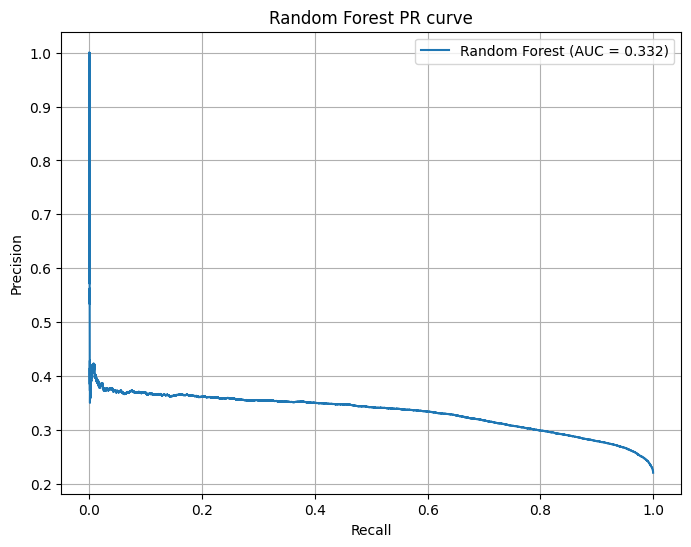

⏱️ Evaluation took: 0.58 sec


In [208]:
model_start_time = time.time()
print("\nTraining Random Forest...")
rf = None # Initialize model variable
try:
    # Check if final training data is available
    if 'X_train' in locals() and 'y_train' in locals() and X_train is not None and y_train is not None:
        rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1, n_estimators=150, max_depth=20, min_samples_leaf=10, min_samples_split=20)
        rf.fit(X_train, y_train) # Use final scaled X_train
        print(f"⏱️ RF Training took: {time.time() - model_start_time:.2f} sec")
        results['Random Forest'] = evaluate_model('Random Forest', rf, X_test, y_test) # Use final scaled X_test
    else:
        print("❌ X_train/y_train not ready for model training.")
        results['Random Forest'] = {'pr_auc': -1, 'f1': -1}
except Exception as rf_err:
    print(f"❌ Error training Random Forest: {rf_err}")
    results['Random Forest'] = {'pr_auc': -1, 'f1': -1}


Training LightGBM...
LGBM scale_pos_weight: 3.54
[LightGBM] [Info] Number of positive: 56234, number of negative: 199026
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002908 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5044
[LightGBM] [Info] Number of data points in the train set: 255260, number of used features: 974
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.220301 -> initscore=-1.263914
[LightGBM] [Info] Start training from score -1.263914
⏱️ LGBM Training took: 2.38 sec

--- Evaluating LightGBM ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.52      0.66     85298
           1       0.31      0.77      0.45     24100

    accuracy                           0.58    109398
   macro avg       0.60      0.65      0.55    109398
weighted avg       0.76      0.58

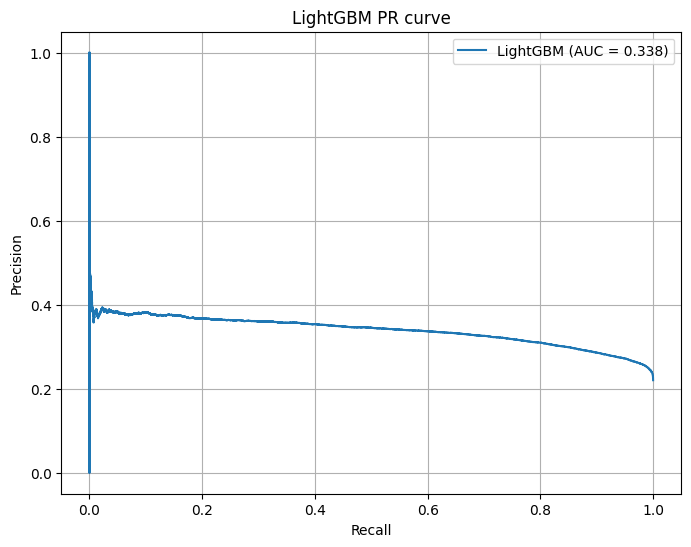

⏱️ Evaluation took: 0.30 sec


In [209]:
if LGBM_AVAILABLE:
    model_start_time = time.time()
    print("\nTraining LightGBM...")
    lgbm = None # Initialize model variable
    try:
         if 'X_train' in locals() and 'y_train' in locals() and X_train is not None and y_train is not None:
            neg_count=np.sum(y_train == 0)
            pos_count=np.sum(y_train == 1)
            scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1
            print(f"LGBM scale_pos_weight: {scale_pos_weight:.2f}")
            lgbm = lgb.LGBMClassifier(objective='binary', metric='aucpr', scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, n_estimators=200, learning_rate=0.05, num_leaves=31)
            lgbm.fit(X_train, y_train) # Use final scaled X_train
            print(f"⏱️ LGBM Training took: {time.time() - model_start_time:.2f} sec")
            results['LightGBM'] = evaluate_model('LightGBM', lgbm, X_test, y_test) # Use final scaled X_test
         else:
             print("❌ X_train/y_train not ready for model training.")
             results['LightGBM'] = {'pr_auc': -1, 'f1': -1}
    except Exception as lgbm_err:
        print(f"❌ Error training LightGBM: {lgbm_err}")
        results['LightGBM'] = {'pr_auc': -1, 'f1': -1}
else:
    print("\nSkipping LightGBM (library not available).")
    results['LightGBM'] = {'pr_auc': -1, 'f1': -1}

In [210]:
best_model_name = None
best_pr_auc = -1 # Initialize with a value lower than any possible valid AUC
best_model_object = None

print("\n--- Model Comparison ---")
# Check if results dictionary is populated
if not results:
     print("No models were successfully trained or evaluated.")
else:
    # Iterate through results and find the best model based on PR AUC
    for name, metrics_dict in results.items():
        # Check if metrics_dict is valid and contains a successful PR AUC calculation
        if isinstance(metrics_dict, dict) and metrics_dict.get('pr_auc', -1) > -1:
            print(f"{name:>20}: PR AUC = {metrics_dict['pr_auc']:.4f}, F1 = {metrics_dict.get('f1', -1):.4f}")
            # Update best model if current model has higher PR AUC
            if metrics_dict['pr_auc'] > best_pr_auc:
                best_pr_auc = metrics_dict['pr_auc']
                best_model_name = name
                # Assign the corresponding trained model object
                if name == 'Random Forest' and 'rf' in locals() and rf is not None:
                    best_model_object = rf
                elif name == 'LightGBM' and LGBM_AVAILABLE and 'lgbm' in locals() and lgbm is not None:
                    best_model_object = lgbm
                # Add elif for other models if tested
        else:
            # Handle cases where evaluation might have failed or was skipped
            print(f"{name:>20}: Evaluation failed, skipped, or PR AUC not applicable.")


--- Model Comparison ---
       Random Forest: PR AUC = 0.3323, F1 = 0.4367
            LightGBM: PR AUC = 0.3384, F1 = 0.4465


## Feature Importance Analysis


--- Random Forest Top 30 Features ---
strikes                0.159227
plate_z                0.143668
balls                  0.098724
plate_x                0.091059
norm_zone_14           0.070422
norm_zone_5            0.052818
norm_zone_11           0.050769
norm_zone_13           0.041307
norm_zone_12           0.023433
norm_zone_8            0.019069
release_spin_rate      0.014067
norm_zone_4            0.013647
pfx_z                  0.013597
release_speed          0.012410
spin_axis              0.012138
effective_speed        0.011613
pfx_x                  0.010941
release_pos_x          0.010548
norm_zone_6            0.010125
sz_top                 0.009501
arm_angle              0.009269
sz_bot                 0.009237
release_pos_z          0.009002
release_extension      0.007156
inning                 0.004528
n_thruorder_pitcher    0.004035
pitch_type_SI          0.003603
outs_when_up           0.003335
norm_zone_2            0.003132
p_throws_R             0.002942
d

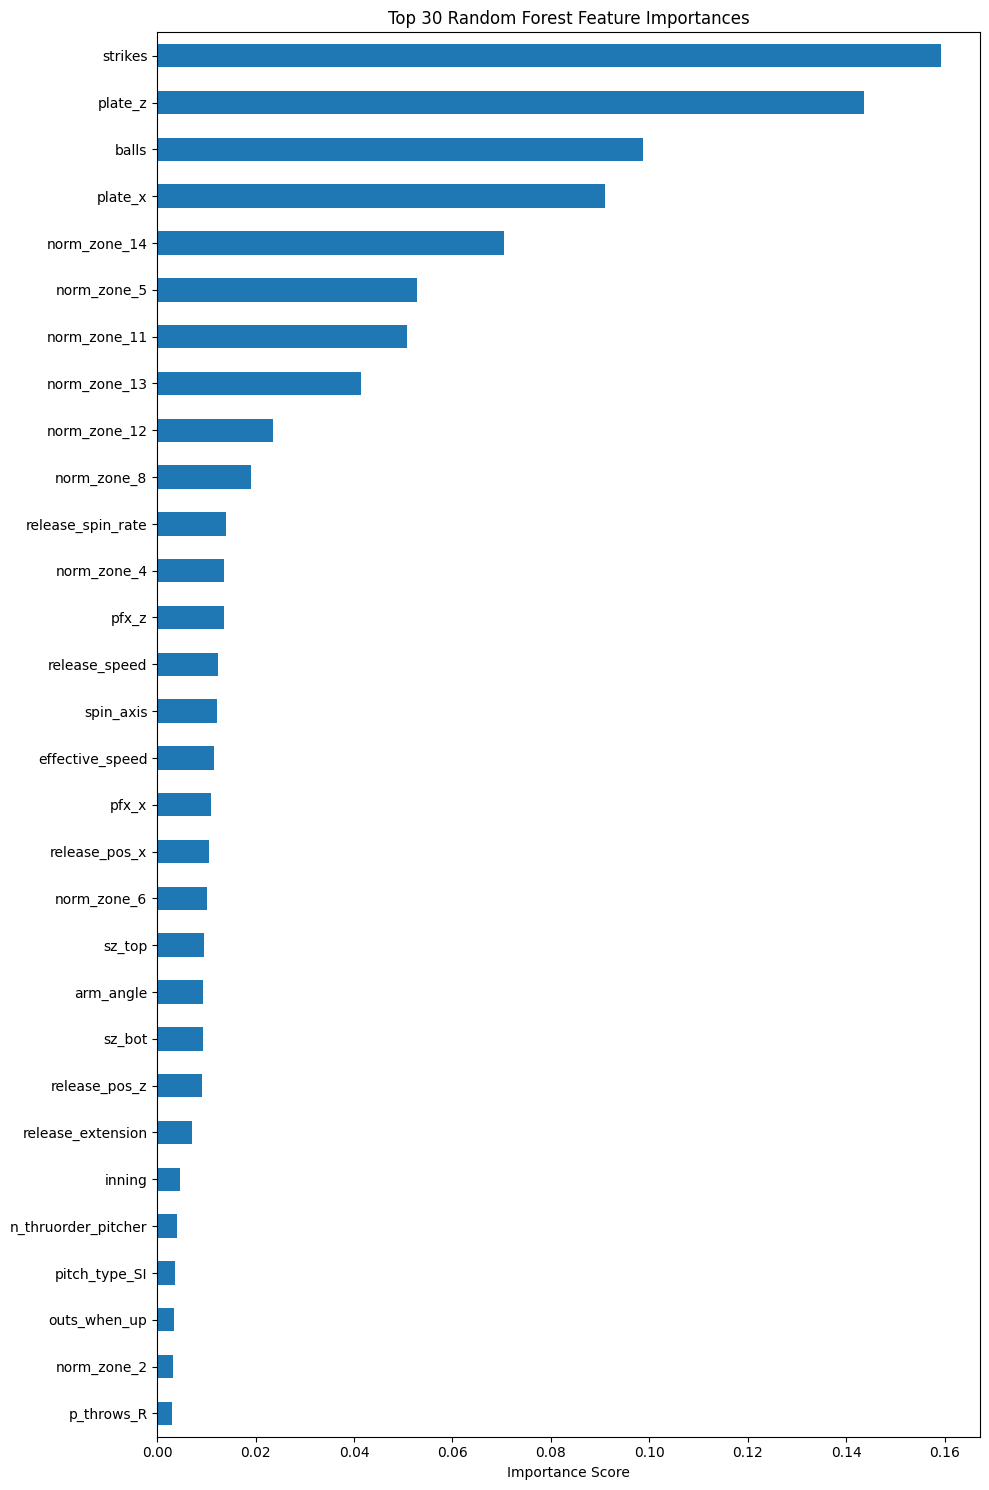

In [199]:
N_FEATURES_TO_SHOW = 30 # How many top features to display

# --- Random Forest Feature Importance ---
if 'rf' in locals() and rf is not None and hasattr(rf, 'feature_importances_'):
    print(f"\n--- Random Forest Top {N_FEATURES_TO_SHOW} Features ---")
    try:
        # Create a pandas Series linking feature names to importance scores
        importances_rf = pd.Series(rf.feature_importances_, index=final_feature_names)
        
        # Sort features by importance
        sorted_importances_rf = importances_rf.sort_values(ascending=False)
        
        # Print the top N
        print(sorted_importances_rf.head(N_FEATURES_TO_SHOW))
        
        # Plot the top N
        plt.figure(figsize=(10, N_FEATURES_TO_SHOW / 2)) # Adjust figure size
        sorted_importances_rf[:N_FEATURES_TO_SHOW].plot(kind='barh')
        plt.title(f'Top {N_FEATURES_TO_SHOW} Random Forest Feature Importances')
        plt.xlabel('Importance Score')
        plt.gca().invert_yaxis() # Display most important at the top
        plt.tight_layout() # Adjust layout
        plt.show()
        
    except Exception as e:
        print(f"❌ Error calculating/plotting Random Forest feature importance: {e}")
else:
    print("\nRandom Forest model ('rf') not found or doesn't have feature importances.")


--- LightGBM Top 30 Features ---
plate_x                954
plate_z                823
pfx_z                  365
balls                  306
pfx_x                  289
sz_bot                 271
sz_top                 270
release_spin_rate      232
arm_angle              210
release_speed          198
release_pos_x          193
release_pos_z          185
effective_speed        166
spin_axis              147
strikes                125
release_extension      122
inning                  70
stand_L                 70
outs_when_up            61
n_thruorder_pitcher     57
runner_on_2b_flag       32
runner_on_3b_flag       24
pitch_type_FF           24
runner_on_1b_flag       22
norm_zone_8             20
pitch_type_FS           19
norm_zone_11            17
norm_zone_5             17
norm_zone_13            14
pitch_type_FA           13
dtype: int32


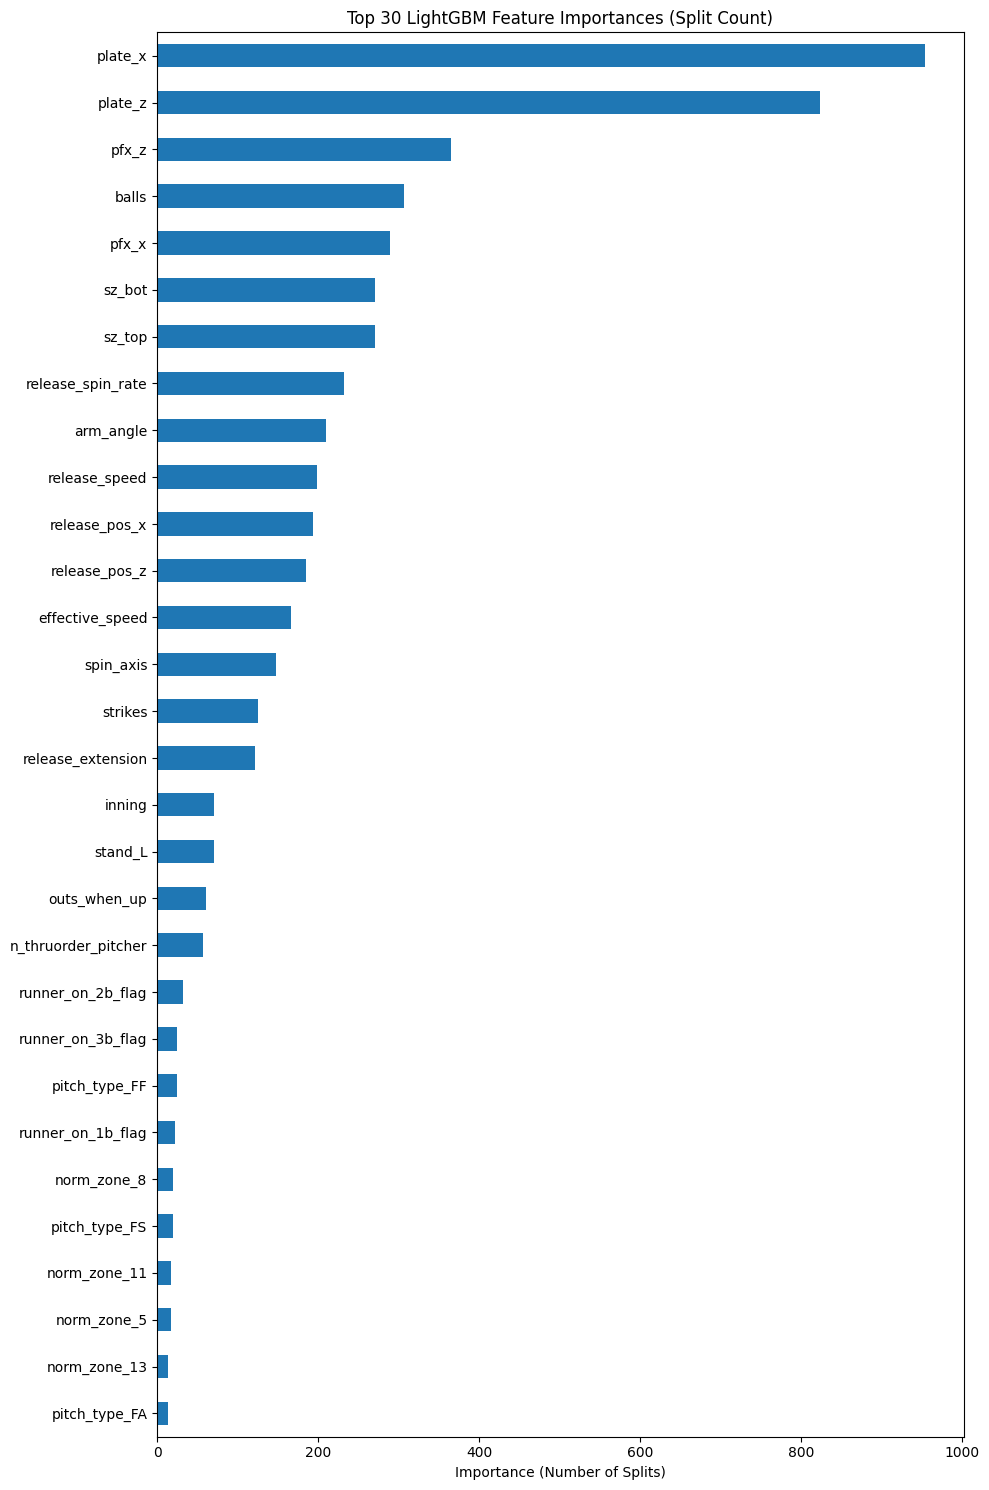

In [200]:
if LGBM_AVAILABLE and 'lgbm' in locals() and lgbm is not None and hasattr(lgbm, 'feature_importances_'):
    print(f"\n--- LightGBM Top {N_FEATURES_TO_SHOW} Features ---")
    try:
        # Create a pandas Series linking feature names to importance scores
        # Note: LGBM importance might be split counts, gain, etc. Default is split counts.
        importances_lgbm = pd.Series(lgbm.feature_importances_, index=final_feature_names)
        
        # Sort features by importance
        sorted_importances_lgbm = importances_lgbm.sort_values(ascending=False)
        
        # Print the top N
        print(sorted_importances_lgbm.head(N_FEATURES_TO_SHOW))
        
        # Plot the top N
        plt.figure(figsize=(10, N_FEATURES_TO_SHOW / 2)) # Adjust figure size
        sorted_importances_lgbm[:N_FEATURES_TO_SHOW].plot(kind='barh')
        plt.title(f'Top {N_FEATURES_TO_SHOW} LightGBM Feature Importances (Split Count)')
        plt.xlabel('Importance (Number of Splits)')
        plt.gca().invert_yaxis() # Display most important at the top
        plt.tight_layout() # Adjust layout
        plt.show()


    except Exception as e:
        print(f"❌ Error calculating/plotting LightGBM feature importance: {e}")
else:
    print("\nLightGBM model ('lgbm') not found, not available, or doesn't have feature importances.")

## Threshold Tuning Analysis

Analyzing probabilities from best model: LightGBM

Threshold maximizing F1 score: 0.5232 (F1 Score: 0.4469)


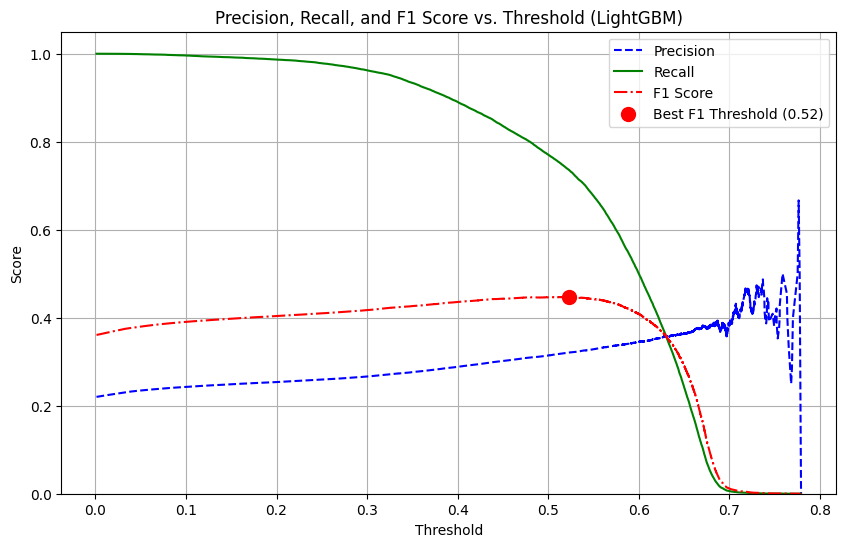


--- Evaluating with custom threshold = 0.5232 ---
Classification Report (Custom Threshold):
              precision    recall  f1-score   support

           0       0.88      0.56      0.69     85298
           1       0.32      0.74      0.45     24100

    accuracy                           0.60    109398
   macro avg       0.60      0.65      0.57    109398
weighted avg       0.76      0.60      0.63    109398

Confusion Matrix (Custom Threshold):
[[47797 37501]
 [ 6372 17728]]
F1 Score (Positive Class, Custom Threshold): 0.4469


In [201]:
# Ensure 'best_model_object' and its name exist from the comparison cell
if 'best_model_object' in locals() and best_model_object is not None and 'best_model_name' in locals():
    print(f"Analyzing probabilities from best model: {best_model_name}")

    # Check if necessary data exists
    if 'X_test' in locals() and 'y_test' in locals() and X_test is not None and y_test is not None:
        try:
            # Re-calculate probabilities for the positive class (safer than relying on evaluate_model state)
            if hasattr(best_model_object, "predict_proba"):
                probabilities = best_model_object.predict_proba(X_test)
                
                if probabilities.shape[1] == 2:
                    y_proba_positive = probabilities[:, 1] # Probability of class 1

                    # Get precision, recall, thresholds
                    precision, recall, thresholds = precision_recall_curve(y_test, y_proba_positive)

                    # Plot Precision-Recall vs Threshold
                    plt.figure(figsize=(10, 6))
                    # Plot precision and recall - note thresholds array is 1 element shorter
                    plt.plot(thresholds, precision[:-1], "b--", label="Precision")
                    plt.plot(thresholds, recall[:-1], "g-", label="Recall")
                    
                    # Calculate F1 score for each threshold
                    # Need to avoid division by zero if precision+recall is 0
                    f1_scores = np.zeros_like(thresholds)
                    non_zero_sum = (precision[:-1] + recall[:-1]) > 0
                    f1_scores[non_zero_sum] = (2 * precision[:-1][non_zero_sum] * recall[:-1][non_zero_sum]) / (precision[:-1][non_zero_sum] + recall[:-1][non_zero_sum])
                    
                    # Find the threshold that maximizes F1 score
                    best_threshold_idx = np.argmax(f1_scores)
                    best_threshold_f1 = thresholds[best_threshold_idx]
                    max_f1 = f1_scores[best_threshold_idx]
                    
                    print(f"\nThreshold maximizing F1 score: {best_threshold_f1:.4f} (F1 Score: {max_f1:.4f})")
                    
                    # Plot F1 score on the same graph
                    plt.plot(thresholds, f1_scores, "r-.", label="F1 Score")
                    # Mark the best threshold
                    plt.scatter(best_threshold_f1, max_f1, marker='o', color='red', label=f'Best F1 Threshold ({best_threshold_f1:.2f})', s=100, zorder=5)

                    plt.xlabel("Threshold")
                    plt.ylabel("Score")
                    plt.title(f'Precision, Recall, and F1 Score vs. Threshold ({best_model_name})')
                    plt.legend(loc='best')
                    plt.grid(True)
                    plt.ylim([0, 1.05]) # Adjust ylim for better visibility
                    plt.show()

                    # --- Example: Evaluate using the best F1 threshold ---
                    print(f"\n--- Evaluating with custom threshold = {best_threshold_f1:.4f} ---")
                    y_pred_custom = (y_proba_positive >= best_threshold_f1).astype(int)
                    
                    print("Classification Report (Custom Threshold):")
                    print(classification_report(y_test, y_pred_custom, zero_division=0))
                    print("Confusion Matrix (Custom Threshold):")
                    cm_custom = confusion_matrix(y_test, y_pred_custom)
                    print(cm_custom)
                    custom_f1 = f1_score(y_test, y_pred_custom, zero_division=0)
                    print(f"F1 Score (Positive Class, Custom Threshold): {custom_f1:.4f}")

                elif probabilities.shape[1] == 1:
                     print("⚠️ Threshold analysis not possible: predict_proba returned only one column.")
                else:
                     print(f"⚠️ Threshold analysis not possible: predict_proba returned unexpected shape {probabilities.shape}.")

            else:
                print("⚠️ Best model object does not have 'predict_proba' method. Cannot perform threshold analysis.")

        except Exception as e:
            print(f"❌ Error during threshold analysis: {e}")
    else:
        print("❌ Cannot perform threshold analysis: X_test or y_test not found.")
else:
    print("⚠️ Cannot perform threshold analysis: Best model object not found or determined.")

## Feature importance and Tuning results 

The models are correctly identifying location and count as key factors. LightGBM also seems to use physical pitch characteristics more effectively than RF in this initial run. However, neither model, with the current basic hyperparameters, can reliably distinguish hits from non-hits with high precision, even after trying to optimize the decision threshold. The models are finding many of the hits (good recall) but are "crying wolf" too often (low precision).

## Hyperparameter Tuning 

In [212]:
if LGBM_AVAILABLE and 'lgbm' in locals() and 'X_train' in locals() and 'y_train' in locals() and X_train is not None and y_train is not None:
    print("Tuning")
    tuning_start_time = time.time()
    
    # --- Define Parameter Distribution ---
    # Define ranges or distributions for parameters to sample from
    # Adjust ranges based on initial results or computational budget
    param_distributions = {
        'n_estimators': randint(100, 501), # Sample between 100 and 500 estimators
        'learning_rate': uniform(0.01, 0.1), # Sample between 0.01 and 0.11
        'num_leaves': randint(20, 61),      # Sample between 20 and 60 leaves
        'max_depth': [-1, 10, 15, 20],     # Fixed options, -1 is no limit
        'reg_alpha': uniform(0.0, 1.0),     # L1 regularization
        'reg_lambda': uniform(0.0, 1.0),    # L2 regularization
        'colsample_bytree': uniform(0.6, 0.4), # Sample between 0.6 and 1.0 (0.6 + 0.4 = 1.0)
        'subsample': uniform(0.6, 0.4),       # Sample between 0.6 and 1.0
        # 'min_child_samples': randint(5, 31) # Min data in leaf (optional)
    }
    
    # --- Base Estimator ---
    # Use the same base settings (like random_state, n_jobs, and scale_pos_weight)
    # Ensure scale_pos_weight is calculated correctly based on y_train
    neg_count = np.sum(y_train == 0); pos_count = np.sum(y_train == 1)
    scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1
    print(f"Using scale_pos_weight: {scale_pos_weight:.2f} in base estimator for tuning.")
    
    base_lgbm = lgb.LGBMClassifier(
        objective='binary',
        metric='aucpr', # Will be overridden by scoring='average_precision' in search
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

Tuning
Using scale_pos_weight: 3.54 in base estimator for tuning.
[LightGBM] [Info] Number of positive: 37489, number of negative: 132684
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028526 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4948
[LightGBM] [Info] Number of data points in the train set: 170173, number of used features: 928
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.220299 -> initscore=-1.263923
[LightGBM] [Info] Start training from score -1.263923
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

### Cross-Validation Strategy

In [213]:
# Use stratified K-Fold for classification with imbalanced data
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) # 3 folds for faster initial run

### Randomized Search Setup

In [214]:
N_ITERATIONS = 25 # Number of parameter settings to try (increase for better search, takes longer)
print(f"Setting up RandomizedSearchCV (n_iter={N_ITERATIONS}, cv={cv_strategy.get_n_splits()})...")

random_search = RandomizedSearchCV(
    estimator=base_lgbm,
    param_distributions=param_distributions,
    n_iter=N_ITERATIONS,       # Number of iterations
    scoring='average_precision', # Optimize for PR AUC
    cv=cv_strategy,            # Cross-validation strategy
    n_jobs=-1,                 # Use all available cores for search
    random_state=42,           # Reproducibility
    verbose=2                  # Show progress
)

Setting up RandomizedSearchCV (n_iter=25, cv=3)...


### Run the search

In [218]:
print("Starting hyperparameter search... (This may take time)")
random_search.fit(X_train, y_train) # Fit on the scaled training data

print(f"\n⏱️ Hyperparameter Search took: {time.time() - tuning_start_time:.2f} seconds")

Starting hyperparameter search... (This may take time)
Fitting 3 folds for each of 25 candidates, totalling 75 fits


KeyboardInterrupt: 

### Show Best results

In [216]:
print("\n--- Best Hyperparameters Found ---")
print(random_search.best_params_)
print(f"\nBest cross-validation PR AUC score: {random_search.best_score_:.4f}")


--- Best Hyperparameters Found ---
{'colsample_bytree': np.float64(0.6431565707973218), 'learning_rate': np.float64(0.013142918568673426), 'max_depth': 15, 'n_estimators': 340, 'num_leaves': 51, 'reg_alpha': np.float64(0.6955160864261275), 'reg_lambda': np.float64(0.1393314544058757), 'subsample': np.float64(0.8417669517111269)}

Best cross-validation PR AUC score: 0.3393


### Evaluate Best Model on Test Set


--- Evaluating Best Tuned Model on Test Set ---

--- Evaluating LightGBM (Tuned) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.53      0.67     85298
           1       0.32      0.76      0.45     24100

    accuracy                           0.58    109398
   macro avg       0.60      0.65      0.56    109398
weighted avg       0.76      0.58      0.62    109398

Confusion Matrix:
[[45382 39916]
 [ 5670 18430]]
Avg. Precision (PR AUC): 0.3388
F1 Score (Pos Class): 0.4471


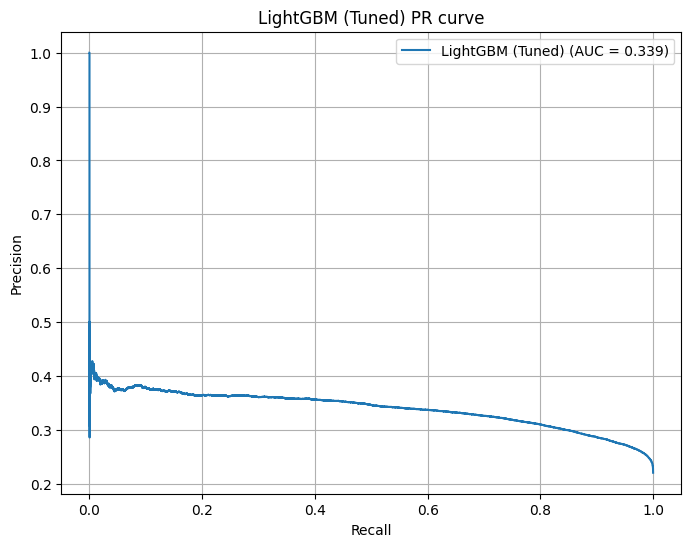

⏱️ Evaluation took: 0.69 sec

Comparison:
Original LGBM PR AUC: 0.3384
Tuned LGBM PR AUC:    0.3388
Original LGBM F1:   0.4465
Tuned LGBM F1:      0.4471
[LightGBM] [Info] Number of positive: 37489, number of negative: 132684
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013478 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4948
[LightGBM] [Info] Number of data points in the train set: 170173, number of used features: 928
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.220299 -> initscore=-1.263923
[LightGBM] [Info] Start training from score -1.263923
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.10507143064099161, max_depth=15, n_estimators=171, num_leaves=40, reg_alpha=0.15601864044243652, reg_lambda=0.15599452033620265, subsample=0.6232334448672797; total time=  30.2s
[LightGBM] [Info] Number of positive: 37489, number of negative: 132684
[LightGBM] [Info] Auto-choosing row-wi

In [217]:
best_lgbm_tuned = random_search.best_estimator_ # Get the best model found
print("\n--- Evaluating Best Tuned Model on Test Set ---")
# Evaluate using the same function as before
results['LightGBM_Tuned'] = evaluate_model('LightGBM (Tuned)', best_lgbm_tuned, X_test, y_test)

if 'LightGBM' in results and results['LightGBM']['pr_auc'] > -1:
    print("\nComparison:")
    print(f"Original LGBM PR AUC: {results['LightGBM']['pr_auc']:.4f}")
    print(f"Tuned LGBM PR AUC:    {results['LightGBM_Tuned']['pr_auc']:.4f}")
    print(f"Original LGBM F1:   {results['LightGBM']['f1']:.4f}")
    print(f"Tuned LGBM F1:      {results['LightGBM_Tuned']['f1']:.4f}")

else:
    print("❌ Cannot perform hyperparameter tuning: Required variables (lgbm, X_train, y_train) not available or LGBM not installed.")


## Best model 

In [221]:
if best_model_object and best_model_name:
    print(f"\n🏆 Best Model selected based on PR AUC: {best_model_name} (PR AUC: {best_pr_auc:.4f})")
    save_output_start_time = time.time()
    print("\nSaving outputs...")
    # Ensure output directory exists
    os.makedirs(MODEL_DIR, exist_ok=True)

    # Save the best model object
    print(f"Saving best model ({best_model_name}) to {MODEL_FILENAME}")
    try:
        with open(MODEL_FILENAME, 'wb') as f:
            pickle.dump(best_model_object, f)
    except Exception as e:
        print(f"❌ Error saving model: {e}")

    # Save the scaler object (only if it was created/loaded)
    if 'scaler' in locals() and scaler is not None:
        print(f"Saving scaler to {SCALER_FILENAME}")
        try:
            with open(SCALER_FILENAME, 'wb') as f:
                pickle.dump(scaler, f)
        except Exception as e:
            print(f"❌ Error saving scaler: {e}")
    else:
        print("⚠️ Scaler object not found or not created (e.g., no numerical features). Cannot save scaler.")

    # Save the shell DataFrame (only if feature names were determined)
    if 'final_feature_names' in locals() and final_feature_names is not None:
        print(f"Saving DataFrame shell with {len(final_feature_names)} columns to {SHELL_FILENAME}")
        try:
            shell_df = pd.DataFrame(columns=final_feature_names)
            shell_df.to_csv(SHELL_FILENAME, index=False)
        except Exception as e:
             print(f"❌ Error saving DataFrame shell: {e}")
    else:
         print("❌ Feature names list not found. Cannot save DataFrame shell.")

    print("✅ Outputs saving process completed.")
    print(f"⏱️ Saving final outputs took: {time.time() - save_output_start_time:.2f} seconds")

else:
    print("❌ No best model determined (or training/evaluation failed/skipped), skipping saving outputs.")


🏆 Best Model selected based on PR AUC: LightGBM (PR AUC: 0.3384)

Saving outputs...
Saving best model (LightGBM) to ./pitch_prob_model_2023-03-30_to_2024-9-29.sav
Saving scaler to ./pitch_scaler_2023-03-30_to_2024-9-29.sav
Saving DataFrame shell with 1161 columns to ./df_shell_2023-03-30_to_2024-9-29.csv
✅ Outputs saving process completed.
⏱️ Saving final outputs took: 0.02 seconds
